# Tabular classification with `LanguageModelClassifier`

The prompt is every feature; the target is the class label. The classifier **scores** rather than
generates: for a row $x$ and each candidate class $c$ in the fitted `classes_` it serializes the row
with `species = c`, reads the model's mean per-token log-likelihood of the class tokens $\ell(c)$,
and normalizes over the fixed candidate set:

$$ \hat{p}(y = c \mid x) = \frac{e^{\ell(c)}}{\sum_{c'} e^{\ell(c')}}, \qquad \hat{y} = \arg\max_c \hat{p}(c \mid x). $$

Every prediction is a member of `classes_` and `predict_proba` sums to 1. Scoring is deterministic,
so the sampling knobs in `GenerationConfig` (`temperature`, `top_p`, ...) do not affect it.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split

from sklm import LanguageModelClassifier, TrainingConfig

sns.set_theme(style="whitegrid", context="notebook")
SEED = 42

## Data

Iris: four measurements in centimetres, three species. The `(cm)` suffix is dropped to keep the
serialized text short; the split is stratified so each class keeps its proportion on both sides.

In [2]:
data = load_iris(as_frame=True)
X = data.data.rename(columns=lambda c: c.removesuffix(" (cm)"))
y = data.target_names[data.target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)
X_train.head()

,sepal length,sepal width,petal length,petal width
8,4.4,2.9,1.4,0.2
106,4.9,2.5,4.5,1.7
76,6.8,2.8,4.8,1.4
9,4.9,3.1,1.5,0.1
89,5.5,2.5,4.0,1.3


## Fine-tuning

`epochs` defaults to 250 as a ceiling: `fit` holds out 10% of the rows, evaluates on them every
epoch and stops once validation loss has not improved for 5 evaluations, restoring the best
weights. `numeric_noise=0.0` turns off the default training-time perturbation of numeric cells
(see `09-numeric-noise`); the Iris measurements are already coarse. `backend="mlx"` runs on Apple
Silicon; `backend="auto"` picks the installed stack.

In [3]:
clf = LanguageModelClassifier(
    backend="mlx",
    model="mlx-community/distilgpt2",
    training=TrainingConfig(batch_size=8, numeric_noise=0.0),
    random_state=SEED,
).fit(X_train, y_train)

## Evaluation

Accuracy, then the confusion matrix: row $i$, column $j$ counts test rows of true class $i$
predicted as $j$.

HTML(value='')

accuracy: 0.933


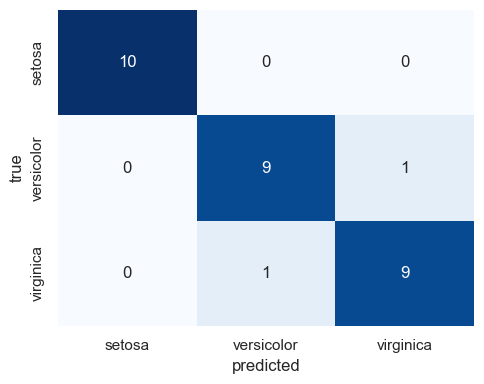

In [4]:
pred = clf.predict(X_test)
print(f"accuracy: {accuracy_score(y_test, pred):.3f}")

cm = confusion_matrix(y_test, pred, labels=clf.classes_)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues", cbar=False,
    xticklabels=clf.classes_, yticklabels=clf.classes_, ax=ax,
)
ax.set_xlabel("predicted")
ax.set_ylabel("true")
plt.tight_layout()
plt.show()

## `predict_proba`

A distribution over `classes_` per row; each row's bars sum to 1.

HTML(value='')

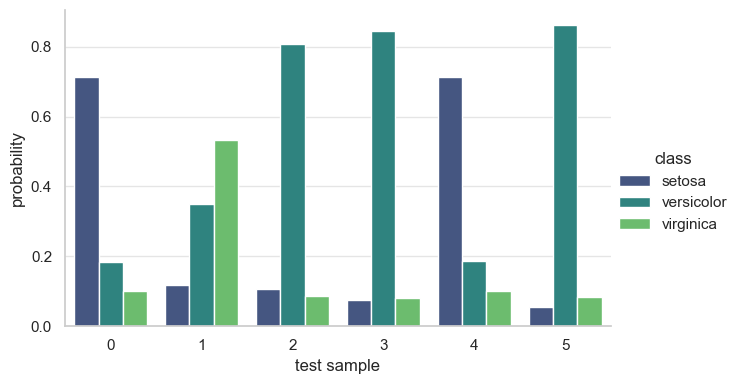

In [5]:
proba = clf.predict_proba(X_test)
proba_df = (
    pd.DataFrame(proba, columns=clf.classes_)
    .head(6)
    .reset_index(names="sample")
    .melt(id_vars="sample", var_name="class", value_name="probability")
)

g = sns.catplot(
    proba_df, kind="bar", x="sample", y="probability", hue="class",
    height=4, aspect=1.6, palette="viridis",
)
g.set_axis_labels("test sample", "probability")
plt.show()